In [1]:
# CamScanner
# Image Transformation - Translate, Rotate, Resize
# Perspective transform

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread("z1.png")

In [4]:
img.shape

(1500, 2667, 3)

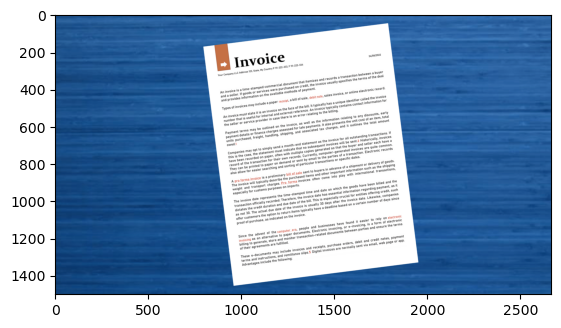

In [6]:
plt.imshow(img)
plt.show()

In [5]:
rows, cols = img.shape[:2]

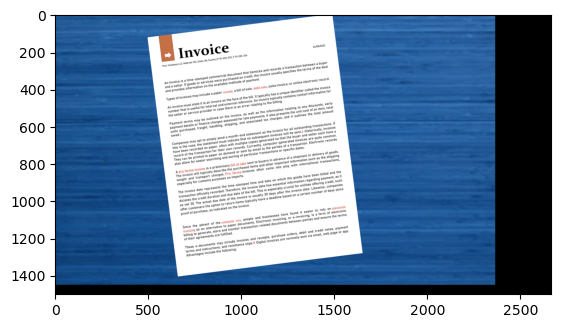

In [13]:
# Translate Image
# create translation matrix
# Format: [[1,0,tx], [0,1,ty]]
# tx - shift along x-axis
# ty - shift along y-axis
matrix = np.float32([[1,0,-300], [0,1,-50]])

# Apply translation
# params: (image, translate_matrix, output_size)
translated = cv2.warpAffine(img, matrix, (cols, rows))
plt.imshow(translated)
plt.show()

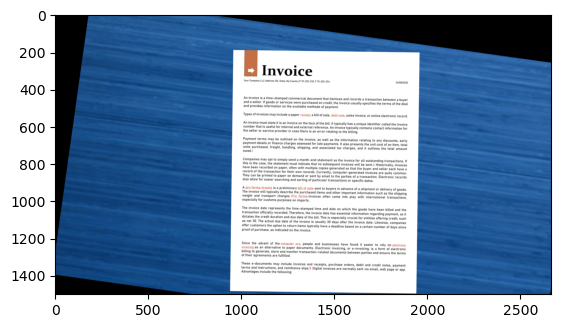

In [18]:
# Rotation
# Center of rotation
center = (rows//2, cols//2)
# Params: (center, angle, scale)
# angle - rotation in degress (positive = counter clockwise)
# scale - zoom (default=1)
matrix = cv2.getRotationMatrix2D(center, -8, 1)
rotated = cv2.warpAffine(img, matrix, (cols, rows))
plt.imshow(rotated)
plt.show()

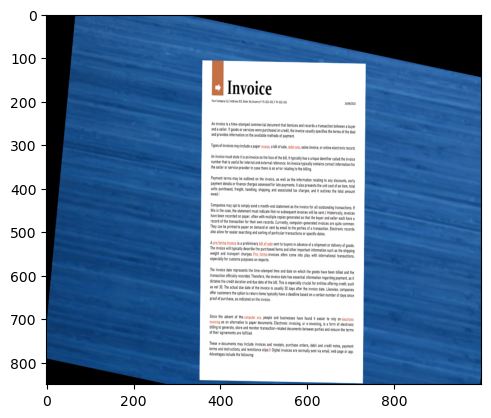

In [21]:
# Resize image
resized = cv2.resize(rotated, (1000,850))
plt.imshow(resized)
plt.show()

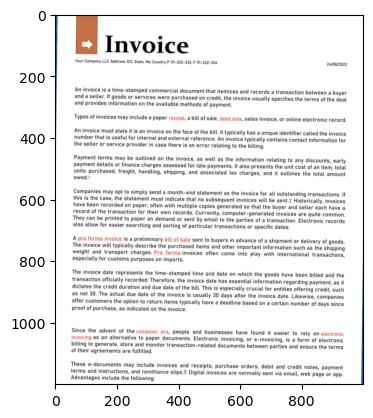

In [30]:
# rotated[start_y:end_y, start_x:end_x]
# first = rows(height - y)
# second = cols(width - x)
cropped = rotated[200:1400, 950:1950]
plt.imshow(cropped)
plt.show()

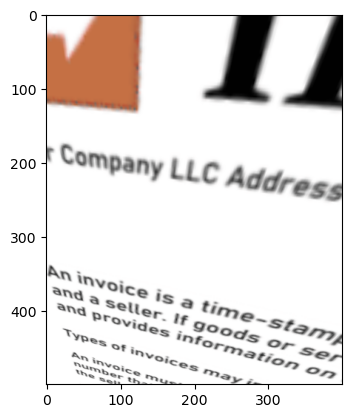

In [38]:
# Perspective Transform
# Convert tilted document - top-down flat view
# source points: [top-left, top-right, bottom-right, bottom-left]
points1 = np.float32([[100,100], [200,100], [300,300], [0,500]])
# destination points
points2 = np.float32([[0,0], [400,0], [400,500], [0,500]])
# Compute perspective
matrix = cv2.getPerspectiveTransform(points1, points2)
warped = cv2.warpPerspective(cropped, matrix, [400,500])
plt.imshow(warped)
plt.show()